[Introduction] 
For the first part of the project, the suspension of a wheel on my first car, a 2019 Honda Civic hatchback, will be modeled after hitting a small bump. This falls in the realm of a spring-mass system; this can be modeled by the second-order ordinary differential equation

my"+cy'+ky=0

where the derivatives of y(t) are in respect to t and
m = mass (kg)
c = damping coefficient (N·s/m)
k = spring constant (N/m)
y(t) = displacement from equilibrium (m)

In order to effectively model the system, the second order equation must be reduced down to a first order system. Let

y1=y
y2=y'

Then,

y1'=y2
y2'=1/m * (-cy2-ky1)

[Parameter Choices] 
The following parameters will be used in the modeling process:

-Vehicle curb weight = 2961 lb
This is the listed curb weight for a 2019 Honda Civic Hatchback. It will need to be converted to kg and divided by 4 to represent the mass supported by one suspension.

-Quarter-car mass, m (kg)
This is the vehicle mass converted to kg and divided by 4.

-Natural frequency, fn (Hz) = 1.3
This is the representative passenger-car suspension frequency. This and the damping ratio are used to estimate realistic values for the spring constant and damping coefficient.

-Damping ratio, zeta = 0.30  
This is a typical value for passenger-car suspension systems. It represents moderate damping, allowing oscillations to decay without excessive stiffness.

-Spring constant, k (N/m)  
This constant relates the natural frequency of the system to the stiffness of the suspension.

-Damping coefficient, c (N·s/m)  
This represents the energy dissipation in the suspension system.

-Initial displacement, y0 (m) = 0.05  
This represents a 0.05 meter vertical displacement caused by the vehicle hitting the small road bump.

-Initial velocity, v0 (m/s) = 0  
This assumes the suspension is momentarily at rest at maximum displacement before oscillation begins.

-Time interval = 0 to 10 seconds
This time interval is chosen to capture the decay of oscillations in the system.

[Parameter Citations]
Edmunds. (n.d.). 2019 Honda Civic Hatchback features & specs. https://www.edmunds.com/honda/civic/2019/hatchback/features-specs/

Rao, S. S. (2017). Mechanical vibrations (6th ed.). Pearson.

Inman, D. J. (2014). Engineering vibration (4th ed.). Pearson.

MIT OpenCourseWare. (2011). Engineering dynamics: Vibration. https://ocw.mit.edu/courses/2-003sc-engineering-dynamics-fall-2011/pages/vibration/

[Numerical Methods Implementation]
The first order differential equation system that was defined in the introduction will be solved using two numerical methods: Euler's Forward and RK4. The Euler's forward method takes the slope at a given time step, and it multiplies it with the size to be added to the current function vaule; this ultimately progresses the approximation. Alternatively, the RK4 method takes a weighted average of slopes at different locations within a time step to make the approximations.

Vehicle mass = 1343.085912 kg
Quarter-car mass m = 335.771478 kg
Spring constant k = 22402.178001516568 N/m
Damping coefficient c = 1645.5772453688676 N*s/m


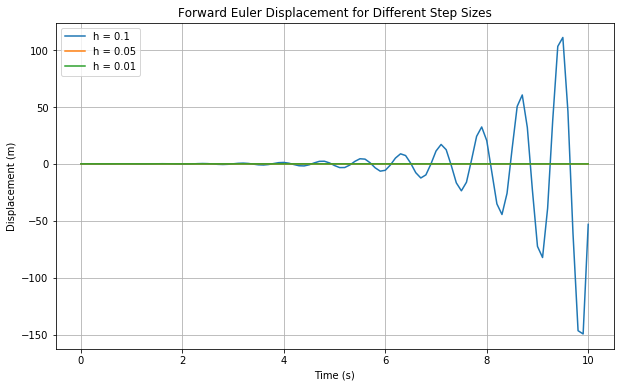

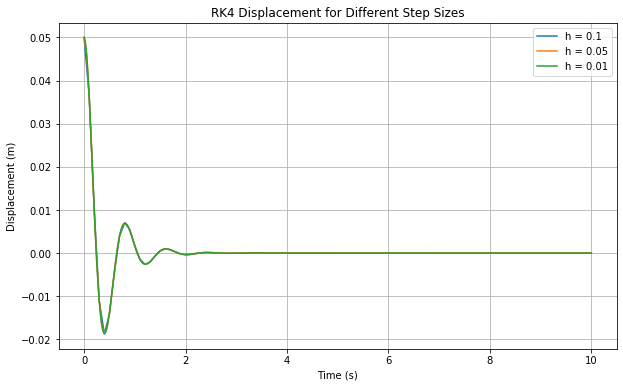

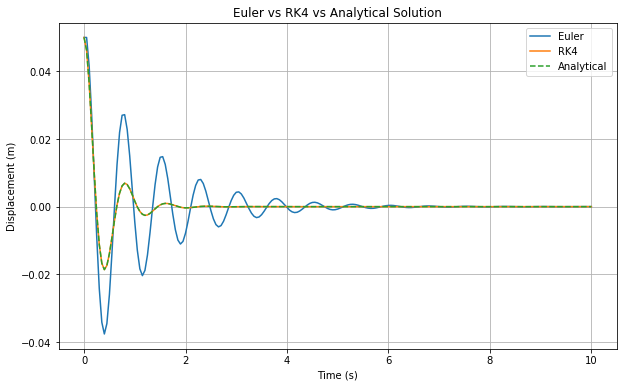

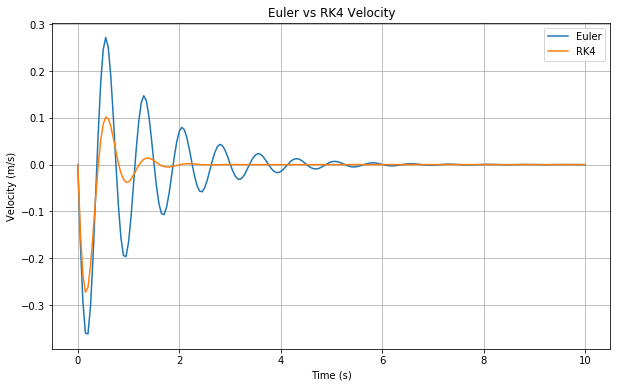

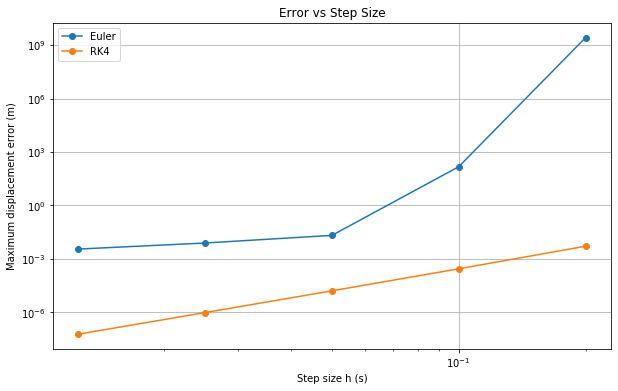

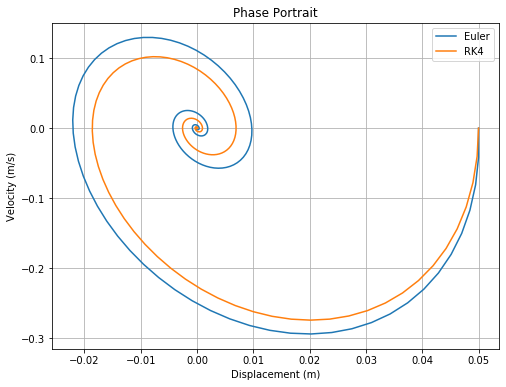

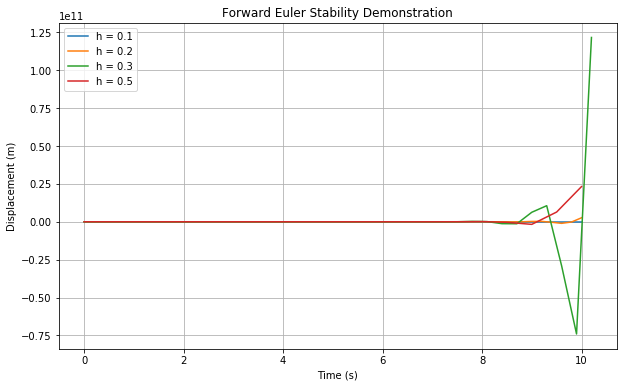

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters------------------------------------------------------------------------------------
vehicle_weight_lb = 2961
vehicle_mass_kg = vehicle_weight_lb * 0.453592

m = vehicle_mass_kg / 4
fn = 1.3
omega_n = 2 * np.pi * fn
zeta = 0.30
k = m * omega_n**2
c = 2 * zeta * m * omega_n
y0 = 0.05
v0 = 0.0
initial_state = np.array([y0, v0])
t0 = 0
tf = 10

print("Vehicle mass =", vehicle_mass_kg, "kg")
print("Quarter-car mass m =", m, "kg")
print("Spring constant k =", k, "N/m")
print("Damping coefficient c =", c, "N*s/m")

# Functions------------------------------------------------------------------------------------
def suspension_system(t, state):
    y = state[0]
    v = state[1]

    dydt = v
    dvdt = -(c/m)*v - (k/m)*y

    return np.array([dydt, dvdt])


def euler_forward(f, t0, tf, h, initial_state):
    t_values = np.arange(t0, tf + h, h)
    states = np.zeros((len(t_values), len(initial_state)))

    states[0] = initial_state

    for i in range(len(t_values) - 1):
        states[i+1] = states[i] + h * f(t_values[i], states[i])

    return t_values, states


def rk4(f, t0, tf, h, initial_state):
    t_values = np.arange(t0, tf + h, h)
    states = np.zeros((len(t_values), len(initial_state)))

    states[0] = initial_state

    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        state = states[i - 1]

        k1 = h * f(t, state)
        k2 = h * f(t + h/2, state + k1/2)
        k3 = h * f(t + h/2, state + k2/2)
        k4 = h * f(t + h, state + k3)

        states[i] = state + (k1 + 2*k2 + 2*k3 + k4)/6

    return t_values, states


def exact_solution(t):
    omega_d = omega_n * np.sqrt(1 - zeta**2)

    A = y0
    B = (v0 + zeta*omega_n*y0) / omega_d

    y = np.exp(-zeta*omega_n*t) * (A*np.cos(omega_d*t) + B*np.sin(omega_d*t))

    return y


# Figure 1: Euler with different step sizes-------------------------------------------------------
step_sizes = [0.1, 0.05, 0.01]

plt.figure(figsize=(10, 6))

for h in step_sizes:
    t_euler, states_euler = euler_forward(suspension_system, t0, tf, h, initial_state)
    plt.plot(t_euler, states_euler[:, 0], label=f"h = {h}")

plt.title("Forward Euler Displacement for Different Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid()
plt.show()


# Figure 2: RK4 with different step sizes----------------------------------------------------------
plt.figure(figsize=(10, 6))

for h in step_sizes:
    t_rk4, states_rk4 = rk4(suspension_system, t0, tf, h, initial_state)
    plt.plot(t_rk4, states_rk4[:, 0], label=f"h = {h}")

plt.title("RK4 Displacement for Different Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid()
plt.show()


# Figure 3: Euler vs RK4 vs analytical solution------------------------------------------------------
h = 0.05

t_euler, states_euler = euler_forward(suspension_system, t0, tf, h, initial_state)
t_rk4, states_rk4 = rk4(suspension_system, t0, tf, h, initial_state)

y_exact = exact_solution(t_euler)

plt.figure(figsize=(10, 6))
plt.plot(t_euler, states_euler[:, 0], label="Euler")
plt.plot(t_rk4, states_rk4[:, 0], label="RK4")
plt.plot(t_euler, y_exact, "--", label="Analytical")

plt.title("Euler vs RK4 vs Analytical Solution")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid()
plt.show()


# Figure 4: Velocity comparison-----------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_euler, states_euler[:, 1], label="Euler")
plt.plot(t_rk4, states_rk4[:, 1], label="RK4")

plt.title("Euler vs RK4 Velocity")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid()
plt.show()

# Figure 5: Error vs step size-------------------------------------------------------------------------
error_step_sizes = [0.2, 0.1, 0.05, 0.025, 0.0125]

euler_errors = []
rk4_errors = []

for h in error_step_sizes:
    t_euler, states_euler = euler_forward(suspension_system, t0, tf, h, initial_state)
    t_rk4, states_rk4 = rk4(suspension_system, t0, tf, h, initial_state)

    exact_euler = exact_solution(t_euler)
    exact_rk4 = exact_solution(t_rk4)

    euler_error = np.max(np.abs(states_euler[:, 0] - exact_euler))
    rk4_error = np.max(np.abs(states_rk4[:, 0] - exact_rk4))

    euler_errors.append(euler_error)
    rk4_errors.append(rk4_error)

plt.figure(figsize=(10, 6))
plt.loglog(error_step_sizes, euler_errors, "o-", label="Euler")
plt.loglog(error_step_sizes, rk4_errors, "o-", label="RK4")

plt.title("Error vs Step Size")
plt.xlabel("Step size h (s)")
plt.ylabel("Maximum displacement error (m)")
plt.legend()
plt.grid()
plt.show()

# Figure 6: Phase portrait
plt.figure(figsize=(8, 6))
plt.plot(states_euler[:, 0], states_euler[:, 1], label="Euler")
plt.plot(states_rk4[:, 0], states_rk4[:, 1], label="RK4")

plt.title("Phase Portrait")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid()
plt.show()


# Stability demonstration---------------------------------------------------------------------------------
large_step_sizes = [0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(10, 6))

for h in large_step_sizes:
    t_large, states_large = euler_forward(suspension_system, t0, tf, h, initial_state)
    plt.plot(t_large, states_large[:, 0], label=f"h = {h}")

plt.title("Forward Euler Stability Demonstration")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid()
plt.show()

[Solutions and Comparison]
The system was solved using the Forward Euler and RK4 methods across multiple step sizes. For the Forward Euler, it is apparent that the displacement of larger step sizes quickly loses its stability and thus accuracy. This should not be the case for such a system, as the displacement should end at 0m. The RK4 method produces more accurate results for all step sizes; it first models the oscillating dispacement, and then it depicts a stable dispacement of 0m for the rest of the time interval. The accuracy of RK4 is more apparent when compared analytically. Additionally, the velocity graph depicts Euler's having a more exaggerated oscilation, whereas the RK4 as a more conservative and realilistic decay.

[Stability Analysis]
The stability of each method can be analyzed by observing how each on behaves as the step sizes increase. With the Forward Euler, there is a clear limitation with larger step sizes. The displacement graphs depict unnatural oscillations that increase in magnitude towards the end of the time interval. The oscillations of suspention should be physically decaying over time and not growing. This notion is rienforced in the stability demonstration graph. The reason that Forward Euler becomes unstable is that numerical errors build up and are amplified at larger step sizes; the method is only conditionally stable. This is in stark contrast to RK4, which remain stable at all step sizes. It's oscillatory decay is realilistic to the senario, and it the overall more accurate method.

[Conclusion]
RK4 is the much better candidate for this specific problem. It maintained stability for all step sizes, and it presented accuracy that closely mirrored the analytical solution. This is in contrast to the Forward Euler method; this method became much more unstable as the step size increased and had exaggerated/unnatural oscillations in its results. Although RK4 is more accurate, it is more complicated and takes more time to compute. This is because it requires more calculations per step, but the natural of the problem negates the computational cost in favor of accuracy. This part of the project demonstrated that choosing the correct method and step size is imperative to effectively model desired data.